In [39]:

# The environment we will be working with
!pip install CityLearn==2.1.2

# For participant interactions (buttons)
!pip install ipywidgets

# To generate static figures
!pip install matplotlib
!pip install seaborn

# Provide standard RL algorithms
!pip install stable-baselines3
!pip install tensorflow
!pip install scikit-learn

# Enable gym compatibility with later stable-baselines3 versions
!pip install shimmy

# Results submission
!pip install requests
!pip install beautifulsoup4

In [40]:
# System operations
import inspect
import os
import uuid

# Date and time
from datetime import datetime

# type hinting
from typing import Any, List, Mapping, Tuple, Union

# Data visualization
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# User interaction
from IPython.display import clear_output
from ipywidgets import Button, FloatSlider, HBox, HTML
from ipywidgets import IntProgress, Text, VBox

# Data manipulation
from bs4 import BeautifulSoup
import math
import numpy as np
import pandas as pd
import random
import re
import requests
import simplejson as json

# LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error


# CityLearn
from citylearn.agents.rbc import HourRBC
from citylearn.agents.q_learning import TabularQLearning
from citylearn.citylearn import CityLearnEnv
from citylearn.data import DataSet
from citylearn.reward_function import RewardFunction
from citylearn.wrappers import NormalizedObservationWrapper
from citylearn.wrappers import StableBaselines3Wrapper
from citylearn.wrappers import TabularQLearningWrapper

# baseline RL algorithms
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback



In [41]:
# set all plotted figures without margins
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.ymargin'] = 0
%matplotlib inline

In [42]:
DATASET_NAME = 'citylearn_challenge_2023_phase_1'
schema = DataSet.get_schema(DATASET_NAME)

In [43]:
root_directory = schema['root_directory']

# change the suffix number in the next code line to a
# number between 1 and 17 to preview other buildings
building_name = 'Building_'
building_data = []
for i in range(1, 4):
  print("building_" + str(i) + "\n")
  filename = schema['buildings'][building_name + str(i)]['energy_simulation']
  filepath = os.path.join(root_directory, filename)
  building_data.append(pd.read_csv(filepath))
  display(building_data[i - 1].head())
  print("\n\n\n")

building_1



,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
0,6,1,5,0,23.098652,-0.123570,61.086187,0.356839,0.055682,1.119216,0.0,0.0,3.0,23.222222,1
1,6,2,5,0,22.234742,0.012520,64.361378,0.345078,0.159338,1.469638,0.0,0.0,3.0,22.222222,1
2,6,3,5,0,22.223061,0.000838,64.493415,0.338769,0.057004,1.458372,0.0,0.0,3.0,22.222222,1
3,6,4,5,0,22.222251,0.000029,64.769702,0.334856,0.000000,1.337342,0.0,0.0,3.0,22.222222,1
4,6,5,5,0,22.222236,0.000014,65.152120,0.348607,0.000000,1.163453,0.0,0.0,3.0,22.222222,1






building_2



,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
0,6,1,5,0,24.278513,-0.165932,60.703619,0.187333,0.0,0.0,0.0,0.0,1.0,24.444444,1
1,6,2,5,0,24.264734,-0.179711,61.140690,0.185918,0.0,0.0,0.0,0.0,1.0,24.444444,1
2,6,3,5,0,24.214114,-0.230331,61.779375,0.184616,0.0,0.0,0.0,0.0,1.0,24.444444,1
3,6,4,5,0,24.119434,-0.325011,62.557429,0.187352,0.0,0.0,0.0,0.0,1.0,24.444444,1
4,6,5,5,0,23.995500,-0.448944,64.078801,0.202237,0.0,0.0,0.0,0.0,1.0,24.444444,1






building_3



,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
0,6,1,5,0,24.431563,-1.288156e-02,57.864119,0.422080,0.0,0.557905,0.0,0.0,2.0,24.444444,1
1,6,2,5,0,24.444383,-6.162604e-05,58.086218,0.419002,0.0,0.221397,0.0,0.0,2.0,24.444444,1
2,6,3,5,0,24.444445,9.792859e-07,58.383119,0.416603,0.0,0.119271,0.0,0.0,2.0,24.444444,1
3,6,4,5,0,24.444440,-4.807433e-06,59.098372,0.418830,0.0,0.060403,0.0,0.0,2.0,24.444444,1
4,6,5,5,0,24.361916,-8.252885e-02,60.374480,0.435160,0.0,0.000000,0.0,0.0,1.0,24.444444,1


Descrizione degli attributi:

In [44]:
for df in building_data:
    display(df.describe(include='all'))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
count,720.0,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.0
mean,6.0,12.500000,4.100000,0.0,24.024244,0.003642,57.808784,0.625618,0.213675,3.333438,0.0,200.066115,2.268056,24.020602,1.0
std,0.0,6.926999,1.973679,0.0,1.538245,0.042871,4.707318,0.810932,0.469465,1.827450,0.0,243.372592,0.838292,1.548475,0.0
min,6.0,1.000000,1.000000,0.0,19.999914,-0.238674,46.463528,0.319633,0.000000,0.000000,0.0,0.000000,0.000000,20.000000,1.0
25%,6.0,6.750000,2.000000,0.0,22.332080,-0.000159,54.488177,0.355172,0.000000,2.076277,0.0,0.000000,2.000000,22.319444,1.0
50%,6.0,12.500000,4.000000,0.0,24.444309,0.000007,57.407697,0.405048,0.000000,3.043866,0.0,35.825707,3.000000,24.444444,1.0
75%,6.0,18.250000,6.000000,0.0,24.444459,0.000476,61.325861,0.528865,0.218549,4.262129,0.0,422.030274,3.000000,24.444444,1.0
max,6.0,24.000000,7.000000,0.0,27.222233,0.353503,67.854749,7.458969,4.565351,10.608549,0.0,703.628269,3.000000,27.222222,1.0


,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
count,720.0,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.0
mean,6.0,12.500000,4.100000,0.0,24.652006,-0.043596,57.896065,0.448812,0.062562,1.744734,0.0,200.066115,0.744444,24.695602,1.0
std,0.0,6.926999,1.973679,0.0,0.577918,0.162962,4.694232,0.607980,0.218332,1.350848,0.0,243.372592,0.436476,0.575547,0.0
min,6.0,1.000000,1.000000,0.0,21.675275,-1.460924,48.831596,0.168683,0.000000,0.000000,0.0,0.000000,0.000000,21.666667,1.0
25%,6.0,6.750000,2.000000,0.0,24.443069,-0.006938,54.278546,0.202237,0.000000,0.537145,0.0,0.000000,0.000000,24.555556,1.0
50%,6.0,12.500000,4.000000,0.0,24.993994,-0.002630,57.127429,0.359115,0.000000,1.551315,0.0,35.825707,1.000000,25.000000,1.0
75%,6.0,18.250000,6.000000,0.0,24.997722,-0.001465,60.704570,0.544013,0.000000,2.728921,0.0,422.030274,1.000000,25.000000,1.0
max,6.0,24.000000,7.000000,0.0,25.548622,0.303706,78.106060,8.825168,3.311841,5.876511,0.0,703.628269,1.000000,25.555556,1.0


,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature (C),Average Unmet Cooling Setpoint Difference (C),Indoor Relative Humidity (%),Equipment Electric Power (kWh),DHW Heating (kWh),Cooling Load (kWh),Heating Load (kWh),Solar Generation (W/kW),Occupant Count (people),Temperature Set Point (C),HVAC Mode (Off/Cooling/Heating)
count,720.0,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.0
mean,6.0,12.500000,4.100000,0.0,24.178425,-0.000124,59.549204,0.877447,0.152430,2.105905,0.0,200.066115,1.434722,24.178549,1.0
std,0.0,6.926999,1.973679,0.0,0.352739,0.014624,2.889132,0.850508,0.418799,1.394574,0.0,243.372592,0.759668,0.355186,0.0
min,6.0,1.000000,1.000000,0.0,22.777896,-0.261994,53.479610,0.397155,0.000000,0.000000,0.0,0.000000,0.000000,22.777778,1.0
25%,6.0,6.750000,2.000000,0.0,23.888916,-0.000006,57.699386,0.452230,0.000000,0.867439,0.0,0.000000,1.000000,23.888889,1.0
50%,6.0,12.500000,4.000000,0.0,24.444245,0.000005,59.312934,0.779240,0.000000,1.860189,0.0,35.825707,2.000000,24.444444,1.0
75%,6.0,18.250000,6.000000,0.0,24.444449,0.000009,61.301241,0.993199,0.058597,3.192224,0.0,422.030274,2.000000,24.444444,1.0
max,6.0,24.000000,7.000000,0.0,24.444475,0.092478,68.515805,8.399374,5.684579,6.168690,0.0,703.628269,2.000000,24.444444,1.0


Grafico del consumo elettrico e energia prodotta da PV:

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


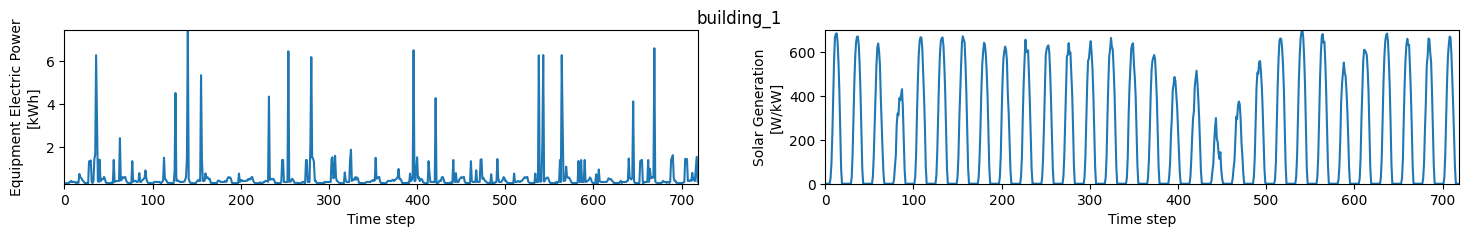

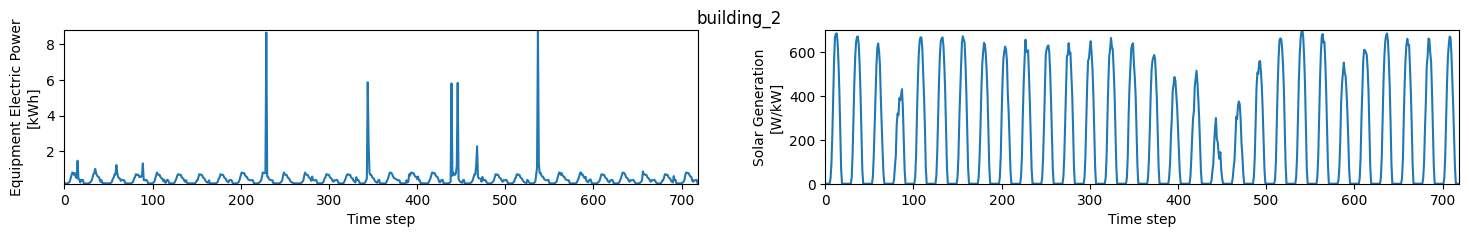

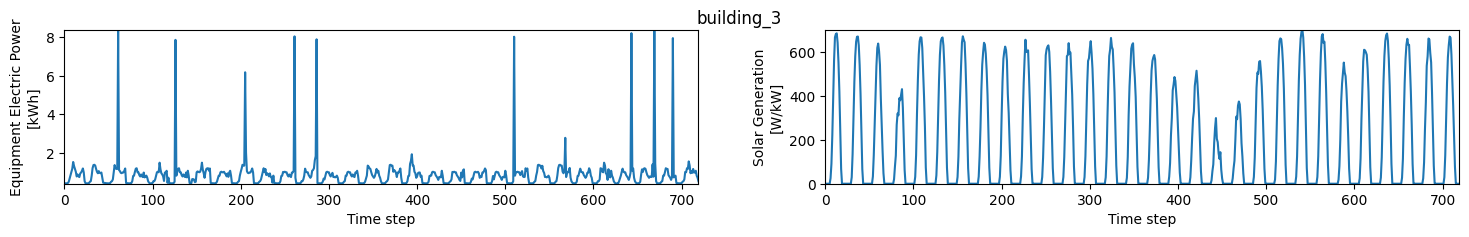

In [45]:
for i in range(1, 4):
  fig, axs = plt.subplots(1, 2, figsize=(18, 2))
  x = building_data[i - 1].index
  y1 = building_data[i-1]['Equipment Electric Power (kWh)']
  y2 = building_data[i-1]['Solar Generation (W/kW)']
  axs[0].plot(x, y1)
  axs[0].set_xlabel('Time step')
  axs[0].set_ylabel('Equipment Electric Power\n[kWh]')
  axs[1].plot(x, y2)
  axs[1].set_xlabel('Time step')
  axs[1].set_ylabel('Solar Generation\n[W/kW]')
  fig.suptitle("building_" + str(i))
  plt.show()

grafico del meteo:

In [46]:
building_name = 'Building_1'
filename = schema['buildings'][building_name]['weather']
filepath = os.path.join(root_directory, filename)
weather_data = pd.read_csv(filepath)
display(weather_data.head())

,Outdoor Drybulb Temperature (C),Outdoor Relative Humidity (%),Diffuse Solar Radiation (W/m2),Direct Solar Radiation (W/m2),6h Outdoor Drybulb Temperature (C),12h Outdoor Drybulb Temperature (C),24h Outdoor Drybulb Temperature (C),6h Outdoor Relative Humidity (%),12h Outdoor Relative Humidity (%),24h Outdoor Relative Humidity (%),6h Diffuse Solar Radiation (W/m2),12h Diffuse Solar Radiation (W/m2),24h Diffuse Solar Radiation (W/m2),6h Direct Solar Radiation (W/m2),12h Direct Solar Radiation (W/m2),24h Direct Solar Radiation (W/m2)
0,24.66,77.56,0.0,0.0,24.910638,38.415958,27.611464,72.980273,41.822361,83.230997,54.625927,116.842886,0.0,143.324335,1020.756093,0.0
1,24.07,85.12,0.0,0.0,27.076564,38.319349,23.515498,87.317655,37.910023,95.353948,78.375479,89.220504,0.0,300.361061,825.097292,0.0
2,23.90,89.62,0.0,0.0,29.351833,39.150482,23.659443,60.341453,30.190199,66.266409,259.822134,82.855932,0.0,196.691127,987.909330,0.0
3,23.87,91.88,0.0,0.0,31.032975,40.934789,26.686004,50.063925,31.519739,94.456370,248.631525,105.130119,0.0,465.483196,854.331825,0.0
4,23.83,93.06,0.0,0.0,33.814467,39.717841,24.467758,40.942579,33.119543,100.000000,272.825159,75.627986,0.0,569.203332,941.243325,0.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


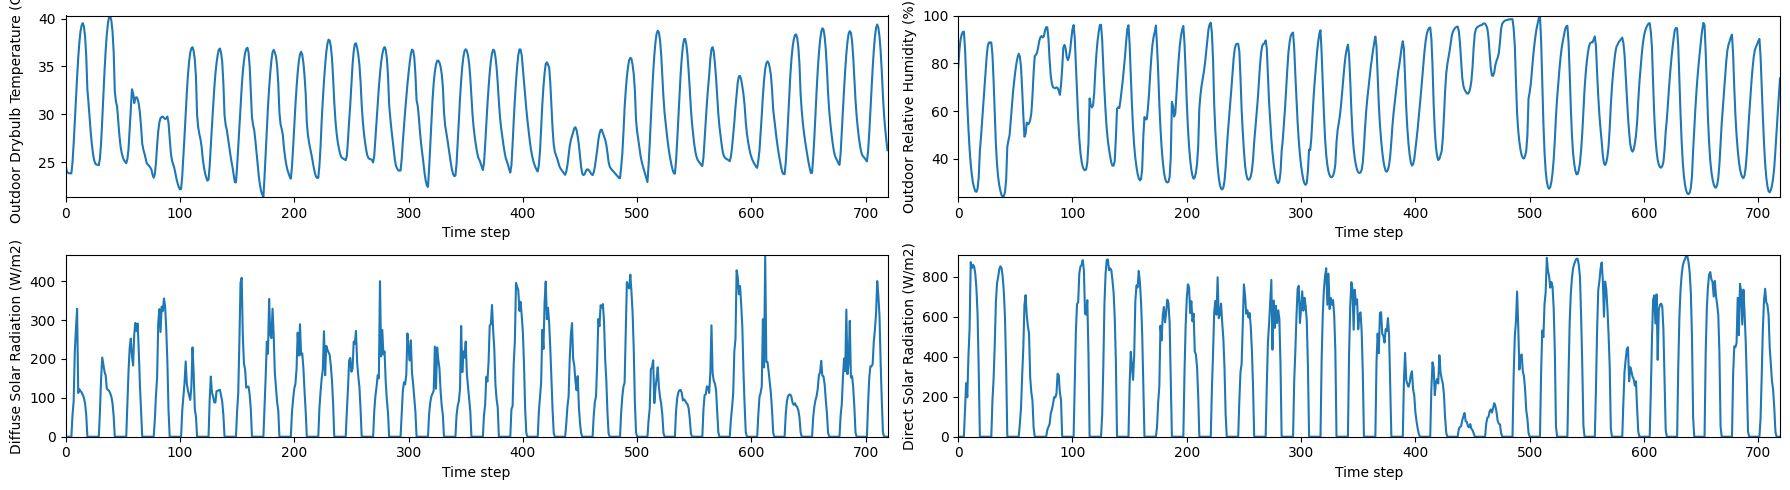

In [47]:
columns = [
    'Outdoor Drybulb Temperature (C)', 'Outdoor Relative Humidity (%)',
    'Diffuse Solar Radiation (W/m2)', 'Direct Solar Radiation (W/m2)'
]
fig, axs = plt.subplots(2, 2, figsize=(18, 5))
x = weather_data.index

for ax, c in zip(fig.axes, columns):
    y = weather_data[c]
    ax.plot(x, y)
    ax.set_xlabel('Time step')
    ax.set_ylabel(c)

fig.align_ylabels()
plt.tight_layout()
plt.show()

### **LSTM**

Ora proponiamo un esempio dell'utilizzo del LSTM con la produzione dei panelli solari corelato al meteo presente:

Qua viene riportato il codice che addestra il modello e visualizza il grafico della perdita durante l'addestramento e la validazione:

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Building_1


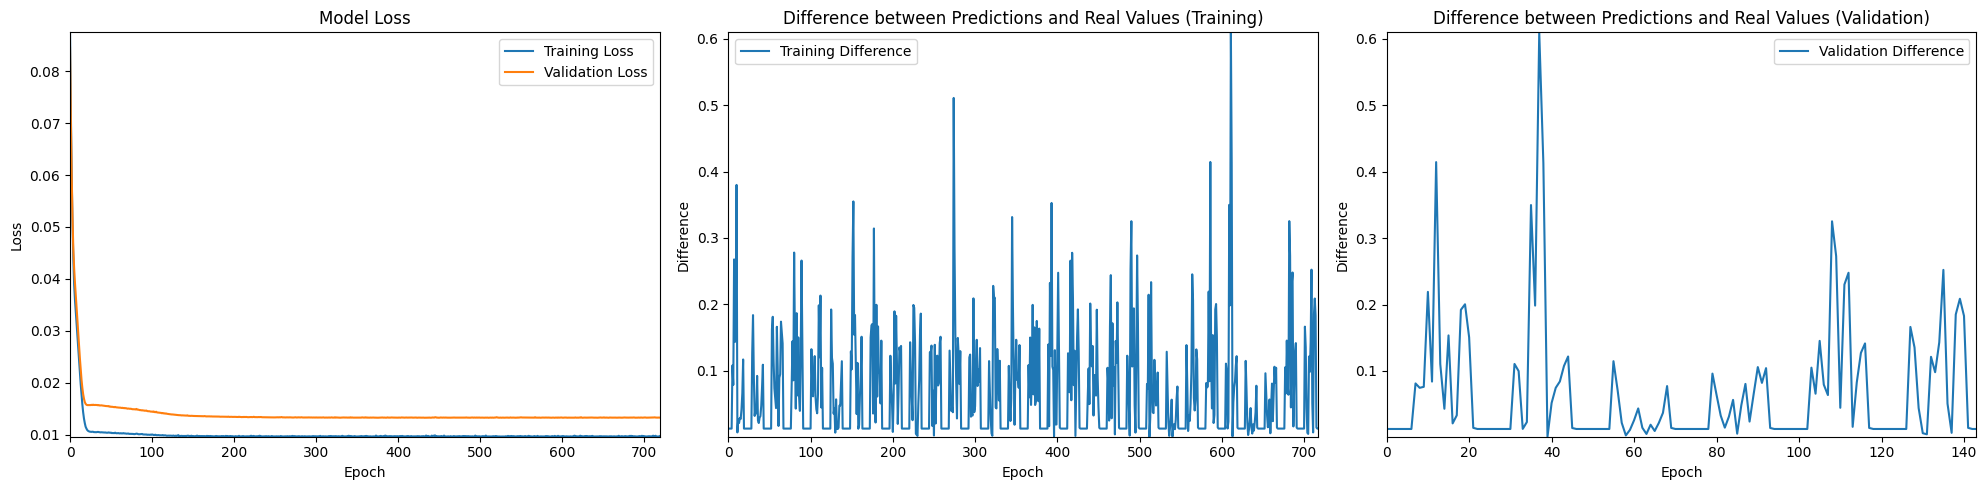

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Building_2


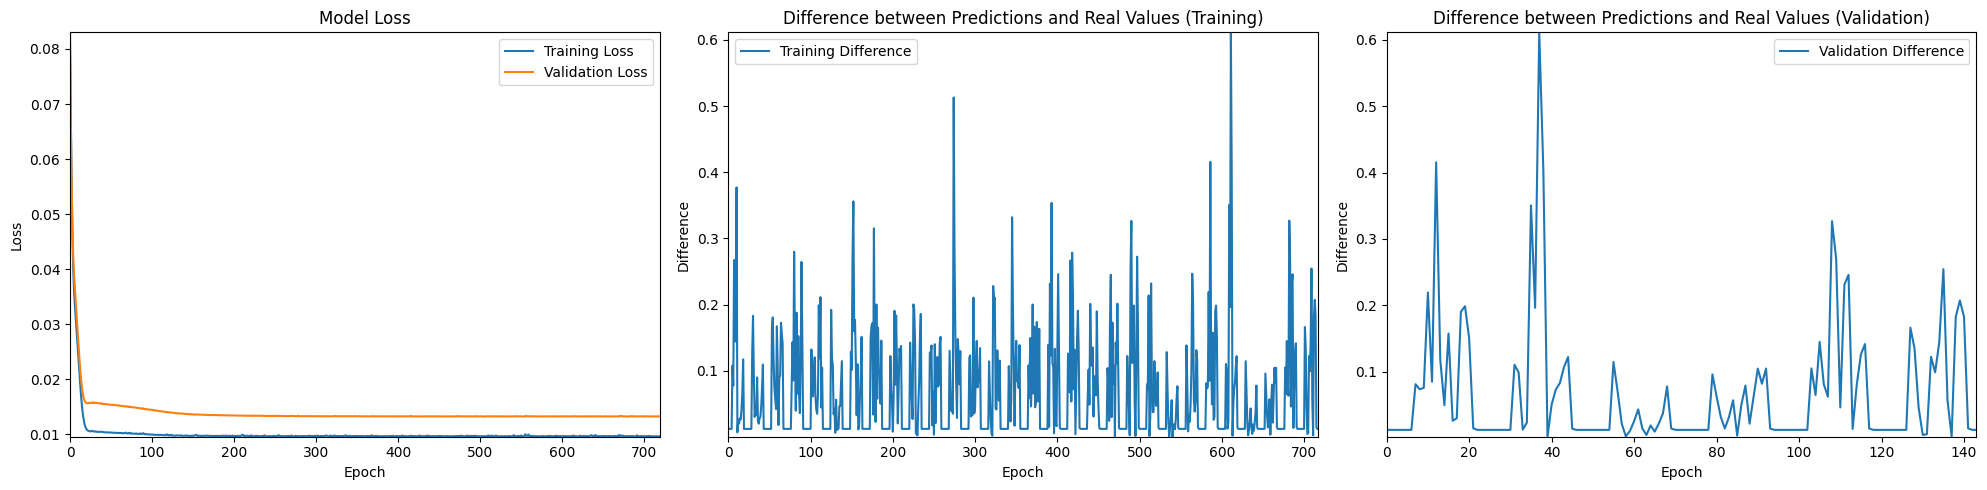

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Building_3


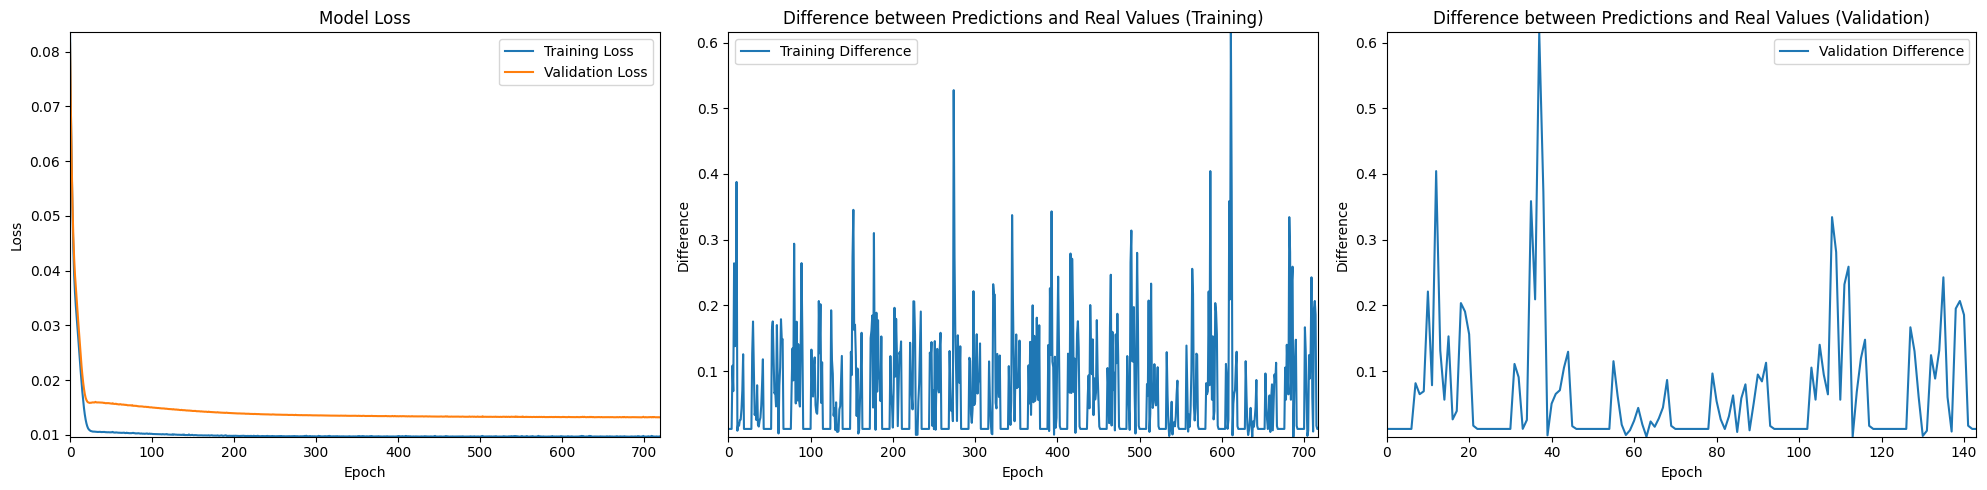

In [48]:
dataset = DataSet.get_schema('citylearn_challenge_2023_phase_1')
root_directory = dataset['root_directory']

building_name = [''] * 3
for i in range(1, 4):
  building_name[i - 1] = 'Building_' + str(i) # Replace with your desired building

weather_filename = [''] * 3
for i in range(1, 4):
  weather_filename[i - 1] = dataset['buildings'][building_name[i - 1]]['weather']

weather_filepath = [''] * 3
for i in range(1, 4):
  weather_filepath[i - 1] = os.path.join(root_directory, weather_filename[i - 1])

data =  [''] * 3
for i in range(1, 4):
  data[i - 1] = pd.read_csv(weather_filepath[i - 1]) # Load the actual weather data


# Filtra i dati per la colonna "Diffuse Solar Radiation (W/m2)"
solar_data = [''] * 3
for i in range(1, 4):
  solar_data[i - 1] = data[i - 1][['Diffuse Solar Radiation (W/m2)']]

# Preprocessa i dati
scaler = MinMaxScaler(feature_range=(0, 1))
values = [''] * 3
scaled_values = [''] * 3
for i in range(1, 4):
  values[i - 1] = solar_data[i - 1].values
  scaled_values[i - 1] = scaler.fit_transform(values[i - 1])

# Prepara i dati con un time step di 6 ore
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 1 #ore
for i in range(1, 4):
  X, y = create_dataset(scaled_values[i - 1], time_step)
  X, y = create_dataset(scaled_values[i - 1], time_step)

  # Reshape i dati per LSTM [samples, time steps, features]
  X = X.reshape((X.shape[0], X.shape[1], 1))

  # Costruisci il modello LSTM
  model = Sequential()
  model.add(LSTM(50, activation='relu', input_shape=(time_step, 1)))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')

  # Addestra il modello
  history = model.fit(X, y, epochs=720, batch_size=32, validation_split=0.2, verbose=0)

  # Prevedi i valori di training e validation
  train_predictions = model.predict(X)
  val_predictions = model.predict(X[int(len(X) * 0.8):])

  # Calcola la differenza tra le previsioni e i valori reali
  train_diff = np.abs(train_predictions - y.reshape(-1, 1))
  val_diff = np.abs(val_predictions - y[int(len(y) * 0.8):].reshape(-1, 1))

  # Traccia i grafici
  print(building_name[i - 1])
  fig, axs = plt.subplots(1, 3, figsize=(20, 5))

  # Primo grafico: Training Loss e Validation Loss
  axs[0].plot(history.history['loss'], label='Training Loss')
  axs[0].plot(history.history['val_loss'], label='Validation Loss')
  axs[0].set_title('Model Loss')
  axs[0].set_xlabel('Epoch')
  axs[0].set_ylabel('Loss')
  axs[0].legend()

  # Secondo grafico: Differenza tra previsioni e valori reali sul training set
  axs[1].plot(train_diff, label='Training Difference')
  axs[1].set_title('Difference between Predictions and Real Values (Training)')
  axs[1].set_xlabel('Epoch')
  axs[1].set_ylabel('Difference')
  axs[1].legend()

  # Terzo grafico: Differenza tra previsioni e valori reali sul validation set
  axs[2].plot(val_diff, label='Validation Difference')
  axs[2].set_title('Difference between Predictions and Real Values (Validation)')
  axs[2].set_xlabel('Epoch')
  axs[2].set_ylabel('Difference')
  axs[2].legend()

  plt.tight_layout()
  plt.show()

Il grafico che viene prodotto dal codice mostra l'andamento della perdita (loss) durante l'addestramento del modello LSTM. Ecco una spiegazione dettagliata del grafico:

**Asse X (Epoch)**: L'asse orizzontale rappresenta il numero di epoche. Un'epoca è un ciclo completo attraverso l'intero dataset durante l'addestramento del modello. In questo caso, il modello è addestrato per 720 epoche.

**Asse Y (Loss)**: L'asse verticale rappresenta la perdita (loss). La perdita è una misura di quanto bene il modello sta facendo nel predire i valori target. Una perdita più bassa indica un modello migliore.

**Linea blu (Training Loss)**: Questa linea mostra la perdita del modello sui dati di addestramento per ogni epoca. È una misura di quanto bene il modello sta facendo sui dati che ha visto durante l'addestramento.

**Linea arancione (Validation Loss)**: Questa linea mostra la perdita del modello sui dati di validazione per ogni epoca. I dati di validazione non sono utilizzati per addestrare il modello, ma servono per valutare quanto bene il modello generalizza su dati non visti.

**Interpretazione del grafico**

*Convergenza*: Idealmente, entrambe le linee (training loss e validation loss) dovrebbero diminuire con il numero di epoche, indicando che il modello sta imparando a fare previsioni migliori.

*Overfitting*: Se la linea della perdita di addestramento continua a diminuire mentre la linea della perdita di validazione inizia ad aumentare, potrebbe indicare che il modello sta overfittando i dati di addestramento. L'overfitting si verifica quando il modello impara troppo bene i dettagli e il rumore nei dati di addestramento, ma non generalizza bene sui dati nuovi.

*Underfitting*: Se entrambe le linee rimangono alte, potrebbe indicare che il modello è sottoaddestrato (underfitting) e non sta imparando bene dai dati.

**LSTM Layer**

La funzione LSTM è utilizzata per aggiungere uno strato LSTM (Long Short-Term Memory) al modello. Gli strati LSTM sono un tipo di rete neurale ricorrente (RNN) che è particolarmente adatta per lavorare con sequenze di dati e serie temporali. Ecco i parametri principali utilizzati nella funzione LSTM:

50: Questo è il numero di unità LSTM (o neuroni) nello strato. Più unità possono catturare più complessità nei dati, ma possono anche aumentare il rischio di overfitting e il tempo di addestramento.

activation='relu': Questo è il tipo di funzione di attivazione utilizzata all'interno delle unità LSTM. La funzione di attivazione ReLU (Rectified Linear Unit) è comunemente usata nelle reti neurali per introdurre non-linearità.

input_shape=(time_step, 1): Questo parametro specifica la forma dell'input che lo strato LSTM si aspetta. In questo caso:
time_step è il numero di passi temporali (sequenze) che stai utilizzando come input.

1 è il numero di caratteristiche per ogni passo temporale. Nel tuo caso, hai una sola caratteristica ("Diffuse Solar Radiation (W/m2)").
Dense Layer
La funzione Dense è utilizzata per aggiungere uno strato denso (fully connected) al modello. Gli strati densi sono strati di base nelle reti neurali in cui ogni neurone è connesso a tutti i neuroni dello strato precedente.

**Dense**:

1: Questo è il numero di neuroni nello strato denso. In questo caso, hai un solo neurone perché stai cercando di prevedere un singolo valore di output (la produzione di radiazione solare diffusa).

Anidride carbonica prodotta:

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/usr/local/lib/python3.10/dist-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


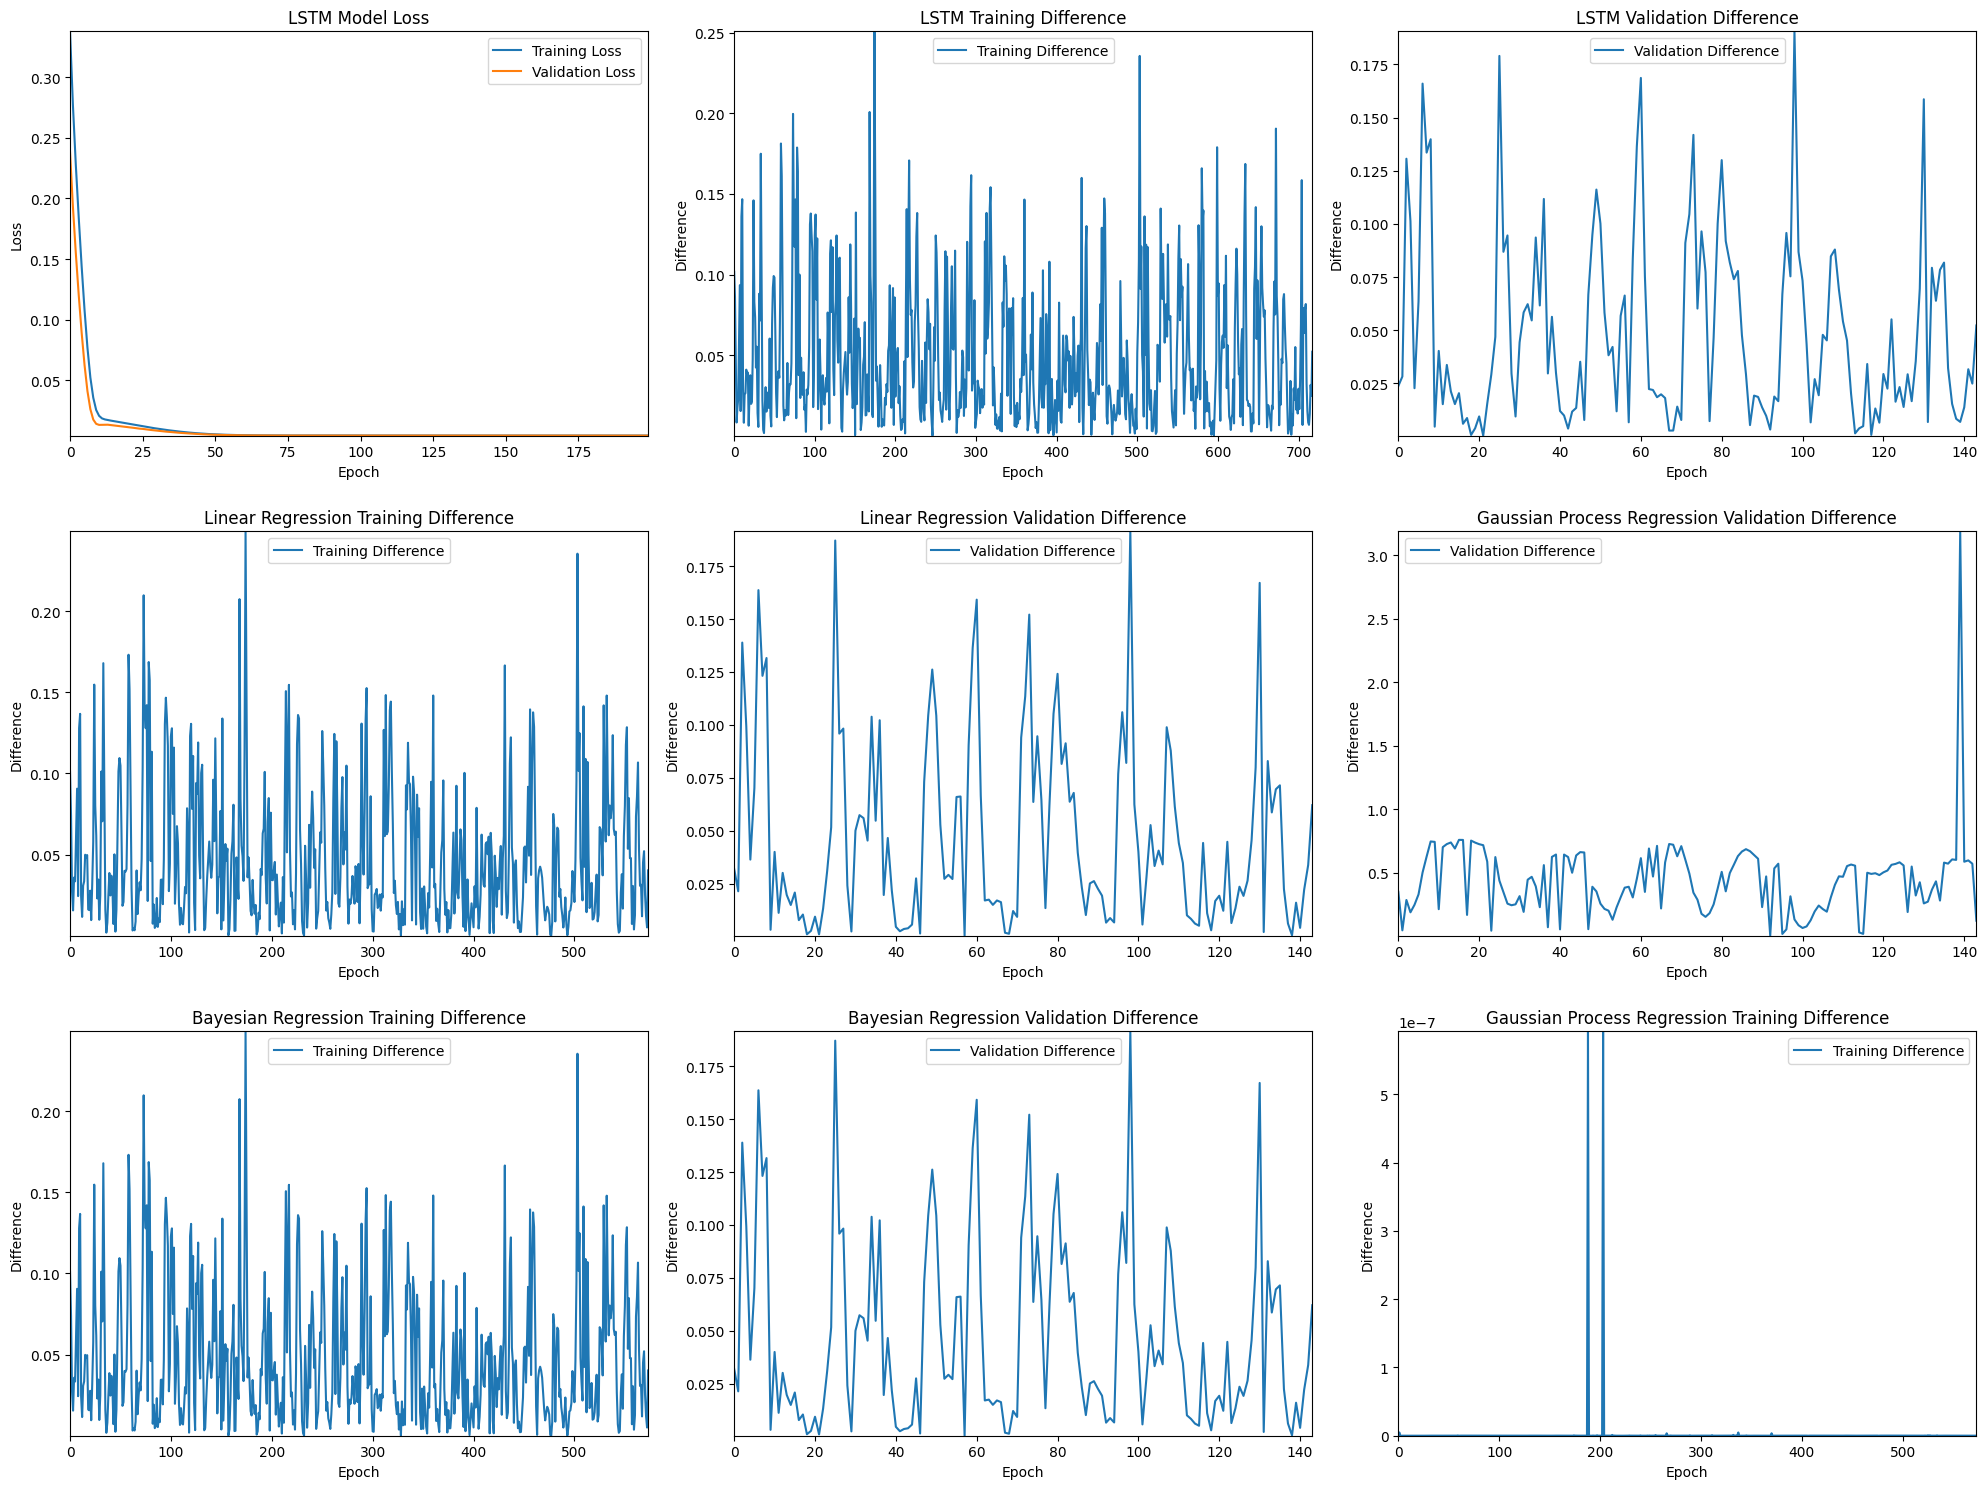

In [49]:
dataset = DataSet.get_schema('citylearn_challenge_2023_phase_1')

root_directory = dataset['root_directory']


building_name = 'Building_1'
filename = schema['buildings'][building_name]['carbon_intensity']
filepath = os.path.join(root_directory, filename)
carbon_intensity_data = pd.read_csv(filepath)

# Preprocessa i dati
values = carbon_intensity_data.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# Prepara i dati con un time step di 6 ore
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 1
X, y = create_dataset(scaled_values, time_step)

# Reshape i dati per LSTM [samples, time steps, features]
X_lstm = X.reshape((X.shape[0], X.shape[1], 1))

# Costruisci il modello LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_step, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Addestra il modello LSTM
history = model.fit(X_lstm, y, epochs=200, batch_size=32, validation_split=0.2, verbose=0)

# Prevedi i valori di training e validation con LSTM
train_predictions_lstm = model.predict(X_lstm)
val_predictions_lstm = model.predict(X_lstm[int(len(X_lstm) * 0.8):])

# Calcola la differenza tra le previsioni e i valori reali per LSTM
train_diff_lstm = np.abs(train_predictions_lstm - y.reshape(-1, 1))
val_diff_lstm = np.abs(val_predictions_lstm - y[int(len(y) * 0.8):].reshape(-1, 1))

# Modelli di regressione
# Dividi i dati in training e validation set
split_index = int(len(X) * 0.8)
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

# Regressione Lineare
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
train_predictions_lr = lr_model.predict(X_train)
val_predictions_lr = lr_model.predict(X_val)

# Regressione Bayesiana
br_model = BayesianRidge()
br_model.fit(X_train, y_train)
train_predictions_br = br_model.predict(X_train)
val_predictions_br = br_model.predict(X_val)

# Regressione con Processo Gaussiano
kernel = C(1.0, (1e-4, 1e1)) * RBF(1, (1e-4, 1e1))
gpr_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr_model.fit(X_train, y_train)
train_predictions_gpr = gpr_model.predict(X_train)
val_predictions_gpr = gpr_model.predict(X_val)

# Calcola la differenza tra le previsioni e i valori reali per i modelli di regressione
train_diff_lr = np.abs(train_predictions_lr - y_train)
val_diff_lr = np.abs(val_predictions_lr - y_val)

train_diff_br = np.abs(train_predictions_br - y_train)
val_diff_br = np.abs(val_predictions_br - y_val)

train_diff_gpr = np.abs(train_predictions_gpr - y_train)
val_diff_gpr = np.abs(val_predictions_gpr - y_val)

# Traccia i grafici
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

# Primo grafico: Training Loss e Validation Loss per LSTM
axs[0, 0].plot(history.history['loss'], label='Training Loss')
axs[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axs[0, 0].set_title('LSTM Model Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()

# Secondo grafico: Differenza tra previsioni e valori reali sul training set per LSTM
axs[0, 1].plot(train_diff_lstm, label='Training Difference')
axs[0, 1].set_title('LSTM Training Difference')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Difference')
axs[0, 1].legend()

# Terzo grafico: Differenza tra previsioni e valori reali sul validation set per LSTM
axs[0, 2].plot(val_diff_lstm, label='Validation Difference')
axs[0, 2].set_title('LSTM Validation Difference')
axs[0, 2].set_xlabel('Epoch')
axs[0, 2].set_ylabel('Difference')
axs[0, 2].legend()

# Quarto grafico: Differenza tra previsioni e valori reali sul training set per Linear Regression
axs[1, 0].plot(train_diff_lr, label='Training Difference')
axs[1, 0].set_title('Linear Regression Training Difference')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Difference')
axs[1, 0].legend()

# Quinto grafico: Differenza tra previsioni e valori reali sul validation set per Linear Regression
axs[1, 1].plot(val_diff_lr, label='Validation Difference')
axs[1, 1].set_title('Linear Regression Validation Difference')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Difference')
axs[1, 1].legend()

# Sesto grafico: Differenza tra previsioni e valori reali sul training set per Bayesian Regression
axs[2, 0].plot(train_diff_br, label='Training Difference')
axs[2, 0].set_title('Bayesian Regression Training Difference')
axs[2, 0].set_xlabel('Epoch')
axs[2, 0].set_ylabel('Difference')
axs[2, 0].legend()

# Settimo grafico: Differenza tra previsioni e valori reali sul validation set per Bayesian Regression
axs[2, 1].plot(val_diff_br, label='Validation Difference')
axs[2, 1].set_title('Bayesian Regression Validation Difference')
axs[2, 1].set_xlabel('Epoch')
axs[2, 1].set_ylabel('Difference')
axs[2, 1].legend()

# Ottavo grafico: Differenza tra previsioni e valori reali sul training set per Gaussian Process Regression
axs[2, 2].plot(train_diff_gpr, label='Training Difference')
axs[2, 2].set_title('Gaussian Process Regression Training Difference')
axs[2, 2].set_xlabel('Epoch')
axs[2, 2].set_ylabel('Difference')
axs[2, 2].legend()

# Nono grafico: Differenza tra previsioni e valori reali sul validation set per Gaussian Process Regression
axs[1, 2].plot(val_diff_gpr, label='Validation Difference')
axs[1, 2].set_title('Gaussian Process Regression Validation Difference')
axs[1, 2].set_xlabel('Epoch')
axs[1, 2].set_ylabel('Difference')
axs[1, 2].legend()

plt.tight_layout()
plt.show()


Preprocessamento dei Dati: Normalizziamo i dati utilizzando MinMaxScaler.

Preparazione dei Dati: Creiamo il dataset con un time step di un'ora.

Costruzione del Modello LSTM: Creiamo un modello LSTM con 50 unità e una funzione di attivazione ReLU.

Addestramento del Modello LSTM: Addestriamo il modello sui dati preprocessati.

Previsioni e Calcolo delle Differenze per LSTM: Prevediamo i valori di training e validation e calcoliamo la differenza tra le previsioni e i valori reali.

Modelli di Regressione: Addestriamo i modelli di regressione lineare, regressione bayesiana e regressione con processo gaussiano sui dati di training e calcoliamo le previsioni e le differenze.

Visualizzazione dei Grafici: Tracciamo i grafici del model loss e delle differenze tra le previsioni e i valori reali per il training set e il validation set per ciascun modello.